# Step 3: Feature Exploration and Sensitivity Analysis
This notebook focuses on the selection of informative summary statistics. 
It includes comparative simulations (High $\beta$/$\rho$ vs. Low $\beta$/$\rho$) to identify features that can effectively decouple the infection and rewiring rates, addressing the parameter non-identifiability challenge.

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from simulator_fast import simulate_fast
from scipy.stats import multivariate_normal
import time

In [2]:
# Load observed data from the 'data' directory
obs_infected = pd.read_csv('data/infected_timeseries.csv')
obs_rewiring = pd.read_csv('data/rewiring_timeseries.csv')
obs_degrees = pd.read_csv('data/final_degree_histograms.csv')

## 2. SMC-ABC Component Functions (Distance & Weighting)

In [3]:
# ---------------------------------------------------------
# 1. Compute summary statistics from the observed data
# ---------------------------------------------------------

# Infection AUC (Area Under the Curve) - Total cumulative infection pressure
auc_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].sum().values

# Standard stats: Peak infected fraction and Total number of rewires
peaks_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].max().values
rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].sum().values

# --- NEW FEATURE: Maximum Step Rewire Rate ---
# This captures the "burstiness" or intensity of the behavioral response.
# High Rho scenarios show a sharp spike in rewiring at the epidemic peak.
max_rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].max().values

# CENTER OF MASS (Infection Timing) - Weighted average of time steps by infection levels
def get_weighted_time(group):
    times = group['time'].values
    fractions = group['infected_fraction'].values
    if np.sum(fractions) == 0: return 1e-6
    return np.sum(times * fractions) / np.sum(fractions)

weighted_time_per_rep = obs_infected.groupby('replicate_id').apply(get_weighted_time).values

# DEGREE VARIANCE (Topology) - Captures the final network structure heterogeneity
obs_degrees['deg_x_count'] = obs_degrees['degree'] * obs_degrees['count']
obs_degrees['deg2_x_count'] = (obs_degrees['degree']**2) * obs_degrees['count']
mean_deg_per_rep = obs_degrees.groupby('replicate_id')['deg_x_count'].sum() / 200
var_deg_per_rep = (obs_degrees.groupby('replicate_id')['deg2_x_count'].sum() / 200) - mean_deg_per_rep**2
var_deg_per_rep = var_deg_per_rep.values

# --- FEATURE UPGRADE: Rewire-to-Infection Ratio ---
# This captures "How aggressively people flee per unit of infection risk"
# Differentiates high-effort/short-duration from low-effort/long-duration scenarios.
rewire_ratio_per_rep = rewires_per_rep / np.maximum(auc_per_rep, 1e-6)

# ---------------------------------------------------------
# 2. Log-transform and build the Feature Matrix (40x5)
# ---------------------------------------------------------
# We now use 5 summary statistics to break the beta-rho equifinality
target_peaks = peaks_per_rep
target_log_ratio = np.log(np.maximum(rewire_ratio_per_rep, 1e-6))
target_log_var_deg = np.log(np.maximum(var_deg_per_rep, 1e-6))
target_log_time = np.log(np.maximum(weighted_time_per_rep, 1e-6))
target_log_max_rewire = np.log(np.maximum(max_rewires_per_rep, 1e-6)) # Added max rewire rate

# Construct the final 40 replicates x 5 summary statistics matrix
X_log_final = np.column_stack([
    target_peaks, 
    target_log_ratio, 
    target_log_var_deg, 
    target_log_time,
    target_log_max_rewire
])

# ---------------------------------------------------------
# 3. Final Target Mu and Std for SMC-ABC (5-dimensional)
# ---------------------------------------------------------
target_mu = np.mean(X_log_final, axis=0)
target_std = np.std(X_log_final, axis=0) 

print("=== NEW 5-Feature Targets (Decoupling Beta & Rho) ===")
print("Features: [Peak, Log Ratio, Log Degree Var, Log Timing, Log Max Rewire]")
print(f"Target Mu : {target_mu}")
print(f"Target Std: {target_std}")

=== NEW 5-Feature Targets (Decoupling Beta & Rho) ===
Features: [Peak, Log Ratio, Log Degree Var, Log Timing, Log Max Rewire]
Target Mu : [0.657125   3.86790725 2.32915881 2.84395716 4.58092127]
Target Std: [0.04212908 0.10240734 0.11783298 0.09236541 0.10346412]


In [4]:
# ---------------------------------------------------------
# 2. SMC-ABC Parameters
# ---------------------------------------------------------
n_particles = 1000  # 1000 particles is usually sufficient for ABC
# Gradually decreasing tolerance (Epsilon)
# The first stage is easy to pass, the final stage is the tightest
epsilons = [5.0, 3.0, 2.0, 1.5] 

# Prior definitions (Uniform)
prior_bounds = np.array([
    [0.05, 0.50],  # beta
    [0.02, 0.20],  # gamma
    [0.0, 0.80]    # rho
])

def prior_pdf(theta):
    if (prior_bounds[0,0] <= theta[0] <= prior_bounds[0,1] and 
        prior_bounds[1,0] <= theta[1] <= prior_bounds[1,1] and 
        prior_bounds[2,0] <= theta[2] <= prior_bounds[2,1]):
        return 1.0 / np.prod(prior_bounds[:, 1] - prior_bounds[:, 0])
    return 0.0

def calculate_distance(sim_stats, target_mu, target_std):
    return np.sqrt(np.sum(((sim_stats - target_mu) / target_std)**2))

## 3. SMC-ABC Iterative Refinement Loop

In [5]:
# ---------------------------------------------------------
# 3. SMC-ABC Core Loop
# ---------------------------------------------------------
np.random.seed(100)  # For reproducibility

print("--- Starting SMC-ABC ---")
particles_history = []
weights_history = []

for gen, eps in enumerate(epsilons):
    start_time = time.time()
    new_particles = np.zeros((n_particles, 3))
    new_weights = np.zeros(n_particles)
    accepted_count = 0
    attempts = 0
    
    if gen > 0:
        # Calculate covariance of previous particles for perturbation
        prev_particles = particles_history[-1]
        prev_weights = weights_history[-1]
        # Weighted covariance matrix * factor (usually 2.0 for exploring)
        cov_matrix = np.cov(prev_particles.T, aweights=prev_weights) * 2.0
    
    while accepted_count < n_particles:
        attempts += 1
        
        # A. Propose a new parameter
        if gen == 0:
            # Gen 0: Sample from prior
            theta_prop = np.array([
                np.random.uniform(prior_bounds[0,0], prior_bounds[0,1]),
                np.random.uniform(prior_bounds[1,0], prior_bounds[1,1]),
                np.random.uniform(prior_bounds[2,0], prior_bounds[2,1])
            ])
        else:
            # Gen > 0: Resample from previous generation and perturb
            idx = np.random.choice(n_particles, p=prev_weights)
            theta_parent = prev_particles[idx]
            theta_prop = np.random.multivariate_normal(theta_parent, cov_matrix)
            
            # Check if out of prior bounds
            if prior_pdf(theta_prop) == 0:
                continue
                
        # B. Run Simulation
        sim_infected, sim_rewires, sim_degrees = simulate_fast(theta_prop[0], theta_prop[1], theta_prop[2])
        
        # C. Calculate Summary Statistics (5-dimensional vector)
        # 1. Peak Infected Fraction
        sim_peak = np.max(sim_infected)
        
        # 2. Rewire-to-Infection Ratio (Log)
        sum_inf = np.sum(sim_infected)
        s_auc = np.maximum(sum_inf, 1e-6) # Guard against zero division
        sim_rewires_tot = np.sum(sim_rewires)
        sim_ratio = sim_rewires_tot / s_auc
        sim_log_ratio = np.log(np.maximum(sim_ratio, 1e-6))
        
        # 3. Final Degree Variance (Log)
        degrees_arr = np.arange(31)
        sim_mean_deg = np.sum(degrees_arr * sim_degrees) / 200
        sim_var_deg = np.sum((degrees_arr**2) * sim_degrees) / 200 - sim_mean_deg**2
        sim_log_var_deg = np.log(np.maximum(sim_var_deg, 1e-6))
        
        # 4. Weighted Infection Timing (Log)
        if sum_inf > 0:
            times_arr = np.arange(len(sim_infected))
            sim_weighted_time = np.sum(times_arr * sim_infected) / sum_inf
        else:
            sim_weighted_time = 1e-6
        sim_log_time = np.log(sim_weighted_time)

        # --- NEW: 5. Maximum Step Rewire Rate (Log) ---
        # Captures the instantaneous intensity of the behavioral response
        sim_max_rewire = np.max(sim_rewires)
        sim_log_max_rewire = np.log(np.maximum(sim_max_rewire, 1e-6))
        
        # --- UPDATED: Construct the 5-feature stats array ---
        sim_stats = np.array([
            sim_peak, 
            sim_log_ratio, 
            sim_log_var_deg, 
            sim_log_time, 
            sim_log_max_rewire
        ])
        
        # D. Calculate Distance
        distance = calculate_distance(sim_stats, target_mu, target_std)
        
        # E. Accept or Reject
        if distance < eps:
            new_particles[accepted_count] = theta_prop
            
            # F. Calculate Weight
            if gen == 0:
                new_weights[accepted_count] = 1.0
            else:
                # Beaumont et al. (2009) weight update formula
                prior_val = prior_pdf(theta_prop)
                # Using the symmetric Gaussian kernel for perturbation
                kernel_vals = multivariate_normal.pdf(prev_particles, mean=theta_prop, cov=cov_matrix)
                denominator = np.sum(prev_weights * kernel_vals)
                new_weights[accepted_count] = prior_val / denominator
                
            accepted_count += 1
            
            if accepted_count % 250 == 0:
                print(f"  Accepted {accepted_count}/{n_particles} (Attempts: {attempts})")

    # Normalize weights
    new_weights = new_weights / np.sum(new_weights)
    
    particles_history.append(new_particles.copy())
    weights_history.append(new_weights.copy())
    
    elapsed = time.time() - start_time
    print(f"Generation {gen} completed. Epsilon: {eps} | Time: {elapsed:.1f}s | Acceptance Rate: {n_particles/attempts:.2%}")

--- Starting SMC-ABC ---
  Accepted 250/1000 (Attempts: 9734)
  Accepted 500/1000 (Attempts: 19021)
  Accepted 750/1000 (Attempts: 28363)
  Accepted 1000/1000 (Attempts: 37218)
Generation 0 completed. Epsilon: 5.0 | Time: 69.8s | Acceptance Rate: 2.69%
  Accepted 250/1000 (Attempts: 5609)
  Accepted 500/1000 (Attempts: 11192)
  Accepted 750/1000 (Attempts: 17470)
  Accepted 1000/1000 (Attempts: 23060)
Generation 1 completed. Epsilon: 3.0 | Time: 30.2s | Acceptance Rate: 4.34%
  Accepted 250/1000 (Attempts: 8569)
  Accepted 500/1000 (Attempts: 16256)
  Accepted 750/1000 (Attempts: 23558)
  Accepted 1000/1000 (Attempts: 30804)
Generation 2 completed. Epsilon: 2.0 | Time: 43.5s | Acceptance Rate: 3.25%
  Accepted 250/1000 (Attempts: 12160)
  Accepted 500/1000 (Attempts: 22937)
  Accepted 750/1000 (Attempts: 34512)
  Accepted 1000/1000 (Attempts: 45130)
Generation 3 completed. Epsilon: 1.5 | Time: 64.7s | Acceptance Rate: 2.22%


## 4. Visualizations


Generating Pairwise Plots for SMC-ABC Final Generation...
Saved pairplot to: plots/smc_abc_pairplot_s5_maximum_step_rewire_rate.pdf


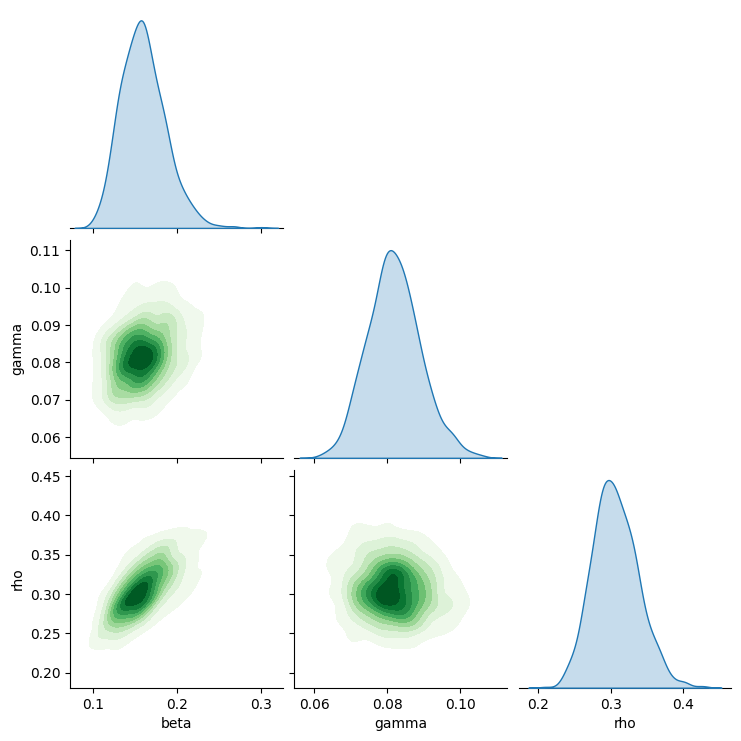

In [6]:
# ---------------------------------------------------------
# 4. Final Posterior Visualization
# ---------------------------------------------------------
final_particles = particles_history[-1]
df_posterior_smc = pd.DataFrame(final_particles, columns=['beta', 'gamma', 'rho'])

print("\nGenerating Pairwise Plots for SMC-ABC Final Generation...")
g = sns.pairplot(df_posterior_smc, kind='kde', corner=True, 
                plot_kws={'fill': True, 'cmap': 'Greens'}) 

pairplot_path = 'plots/smc_abc_pairplot_s5_maximum_step_rewire_rate.pdf'
g.savefig(pairplot_path, format='pdf', bbox_inches='tight')
print(f"Saved pairplot to: {pairplot_path}")

plt.show()

In [7]:
# ---------------------------------------------------------
# 1. Extract extreme parameter sets from the SMC posterior
# ---------------------------------------------------------
# Sort the dataframe by 'beta' to easily find the extremes of the ridge
df_sorted = df_posterior_smc.sort_values(by='beta')

# Select 5 particles with the lowest beta (and consequently lowest rho)
# Extract only the first 3 columns: ['beta', 'gamma', 'rho']
low_params = df_sorted.iloc[:, :3].head(5).values

# Select 5 particles with the highest beta (and consequently highest rho)
high_params = df_sorted.iloc[:, :3].tail(5).values

Simulating dynamics for Low Beta / Low Rho group...
Simulating dynamics for High Beta / High Rho group...
Saved resolved equifinality plot to: plots/smc_abc_SIR_plot_3.pdf


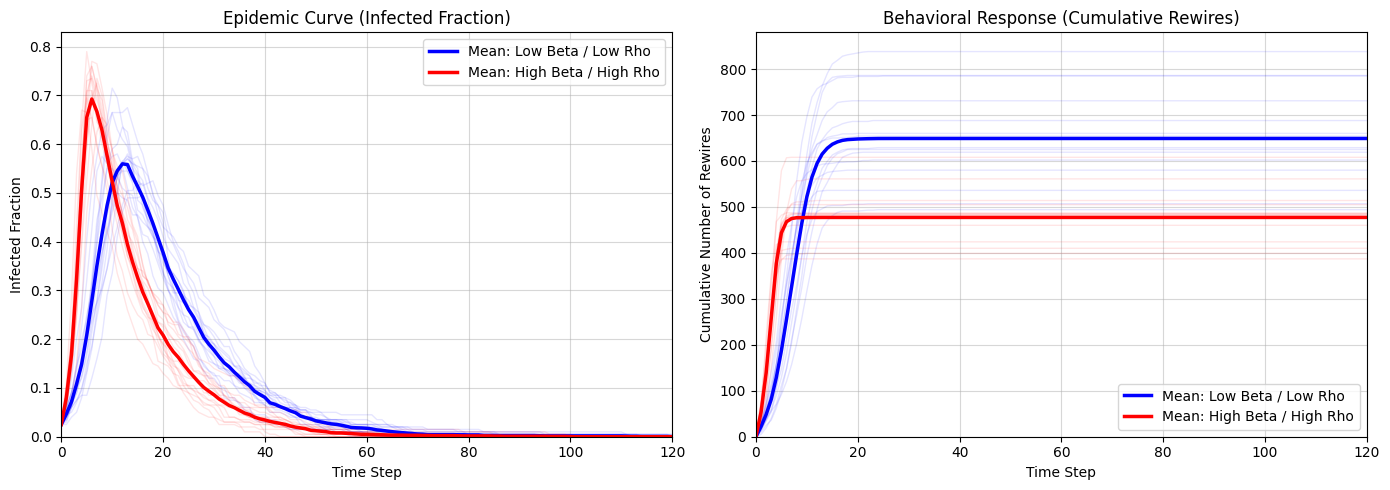

In [8]:
# ---------------------------------------------------------
# 2. Setup the side-by-side plots (1x2 layout)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

low_infected_all, low_rewires_all = [], []
high_infected_all, high_rewires_all = [], []

print("Simulating dynamics for Low Beta / Low Rho group...")
# 3. Simulate and plot for the 'Low beta, Low rho' group
for i, (beta, gamma, rho) in enumerate(low_params):
    for j in range(3):
        sim_infected, sim_rewires, _ = simulate_fast(beta, gamma, rho)
        
        low_infected_all.append(sim_infected)
        low_rewires_all.append(np.cumsum(sim_rewires))
        
        axes[0].plot(sim_infected, color='blue', alpha=0.1, linewidth=1)
        axes[1].plot(np.cumsum(sim_rewires), color='blue', alpha=0.1, linewidth=1)

print("Simulating dynamics for High Beta / High Rho group...")
# 4. Simulate and plot for the 'High beta, High rho' group
for i, (beta, gamma, rho) in enumerate(high_params):
    for j in range(3):
        sim_infected, sim_rewires, _ = simulate_fast(beta, gamma, rho)
        
        high_infected_all.append(sim_infected)
        high_rewires_all.append(np.cumsum(sim_rewires))

        axes[0].plot(sim_infected, color='red', alpha=0.1, linewidth=1)
        axes[1].plot(np.cumsum(sim_rewires), color='red', alpha=0.1, linewidth=1)

# ---------------------------------------------------------
# 4.5. Calculate and plot Mean lines (alpha = 1)
# ---------------------------------------------------------
time_steps = np.arange(len(low_infected_all[0]))

mean_low_infected = np.mean(low_infected_all, axis=0)
mean_low_rewires = np.mean(low_rewires_all, axis=0)
axes[0].plot(time_steps, mean_low_infected, color='blue', alpha=1.0, linewidth=2.5, label='Mean: Low Beta / Low Rho')
axes[1].plot(time_steps, mean_low_rewires, color='blue', alpha=1.0, linewidth=2.5, label='Mean: Low Beta / Low Rho')

mean_high_infected = np.mean(high_infected_all, axis=0)
mean_high_rewires = np.mean(high_rewires_all, axis=0)
axes[0].plot(time_steps, mean_high_infected, color='red', alpha=1.0, linewidth=2.5, label='Mean: High Beta / High Rho')
axes[1].plot(time_steps, mean_high_rewires, color='red', alpha=1.0, linewidth=2.5, label='Mean: High Beta / High Rho')

# ---------------------------------------------------------
# 5. Finalize plot aesthetics
# ---------------------------------------------------------
# Left plot formatting
axes[0].set_title('Epidemic Curve (Infected Fraction)')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Infected Fraction')
axes[0].set_xlim(0, 120)       
axes[0].set_ylim(bottom=0)     
axes[0].margins(x=0, y=0)      
axes[0].legend()
axes[0].grid(True, alpha=0.5)

# Right plot formatting
axes[1].set_title('Behavioral Response (Cumulative Rewires)')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Cumulative Number of Rewires')
axes[1].set_xlim(0, 120)       
axes[1].set_ylim(bottom=0)     
axes[1].margins(x=0, y=0)      
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()

# Save the plot for the report
plt.savefig('plots/smc_abc_SIR_plot_3.pdf', format='pdf', bbox_inches='tight')
print("Saved resolved equifinality plot to: plots/smc_abc_SIR_plot_3.pdf")

plt.show()